In [1]:
from __future__ import annotations

from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
plt.style.use('ggplot')


In [2]:
if Path('data/output_log.csv').exists():
    PROJECT_ROOT = Path('.').resolve()
    DATA_PATH = PROJECT_ROOT / 'data' / 'output_log.csv'
elif Path('output_log.csv').exists():
    PROJECT_ROOT = Path('..').resolve()
    DATA_PATH = Path('output_log.csv').resolve()
else:
    raise FileNotFoundError('Khong tim thay output_log.csv. Hay chay notebook tu root project hoac tu thu muc data/.')

df = pd.read_csv(DATA_PATH)
df.head()


,stationId,destination_stationId,hour,lat,lng,destination_lat,destination_lng,delta_time,estimate_time,predict_time,timestamp
0,1992,323,14,10.872419,106.768248,10.875454,106.758689,141.879610,125.61,153.09,2026-02-01 14:37:18
1,1992,323,16,10.872419,106.768248,10.875454,106.758689,214.738806,160.61,176.47,2026-02-10 16:46:02
2,1992,323,18,10.872419,106.768248,10.875454,106.758689,131.112207,144.44,174.51,2026-02-27 18:06:51
3,1992,323,14,10.872419,106.768248,10.875454,106.758689,197.674791,146.61,153.09,2026-03-16 14:47:01
4,1992,323,7,10.872419,106.768248,10.875454,106.758689,191.282736,146.61,174.34,2026-03-17 07:27:22


In [11]:
print(f'Dataset path: {DATA_PATH}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
display(df.dtypes.to_frame('dtype'))
display(df.isna().sum().to_frame('missing_values'))
display(df.nunique().to_frame('unique_values'))


Dataset path: D:\vinAI\GSM\Map\ETA-prediction\data\output_log.csv
Shape: 308 rows x 11 columns


,dtype
stationId,int64
destination_stationId,int64
hour,int64
lat,float64
lng,float64
destination_lat,float64
destination_lng,float64
delta_time,float64
estimate_time,float64
predict_time,float64


,missing_values
stationId,0
destination_stationId,0
hour,0
lat,0
lng,0
destination_lat,0
destination_lng,0
delta_time,0
estimate_time,0
predict_time,0


,unique_values
stationId,1
destination_stationId,1
hour,18
lat,1
lng,1
destination_lat,1
destination_lng,1
delta_time,308
estimate_time,79
predict_time,18


In [5]:
required_columns = {
    'stationId', 'destination_stationId', 'hour', 'lat', 'lng',
    'destination_lat', 'destination_lng', 'estimate_time','predict_time'
}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f'Missing required columns: {sorted(missing_columns)}')

df = df.copy()
numeric_columns = ['stationId', 'destination_stationId', 'hour', 'lat', 'lng', 'destination_lat', 'destination_lng', 'estimate_time', 'predict_time']
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')

if df[numeric_columns].isna().any().any():
    display(df[numeric_columns].isna().sum().to_frame('missing_after_numeric_cast'))
    raise ValueError('Co gia tri khong ep kieu numeric duoc trong cac cot bat buoc.')

if not df['hour'].between(0, 23).all():
    raise ValueError('Cot hour co gia tri nam ngoai khoang [0, 23].')

route_columns = ['stationId', 'destination_stationId', 'lat', 'lng', 'destination_lat', 'destination_lng']

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
stationId,308.0,1992.000000,0.000000e+00,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000
destination_stationId,308.0,323.000000,0.000000e+00,323.000000,323.000000,323.000000,323.000000,323.000000
hour,308.0,13.243506,4.615770e+00,4.000000,8.750000,16.000000,17.000000,21.000000
lat,308.0,10.872419,1.779248e-15,10.872419,10.872419,10.872419,10.872419,10.872419
lng,308.0,106.768248,1.423398e-14,106.768248,106.768248,106.768248,106.768248,106.768248
destination_lat,308.0,10.875454,3.558495e-15,10.875454,10.875454,10.875454,10.875454,10.875454
destination_lng,308.0,106.758689,1.423398e-14,106.758689,106.758689,106.758689,106.758689,106.758689
delta_time,308.0,188.478946,7.687101e+01,74.199850,144.034672,170.276073,209.080696,891.276558
estimate_time,308.0,157.662338,1.768038e+01,121.610000,144.440000,153.610000,172.860000,192.610000
predict_time,308.0,172.965000,1.633078e+01,128.160000,165.810000,174.510000,176.470000,215.300000


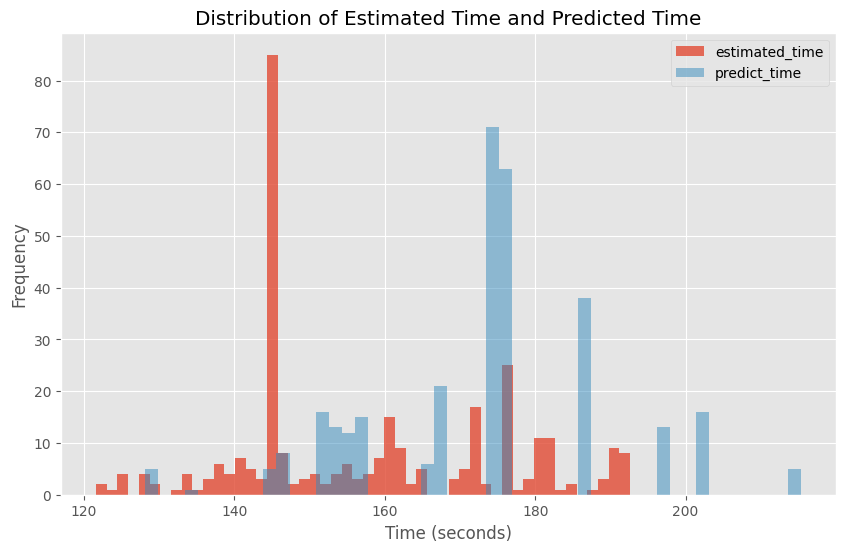

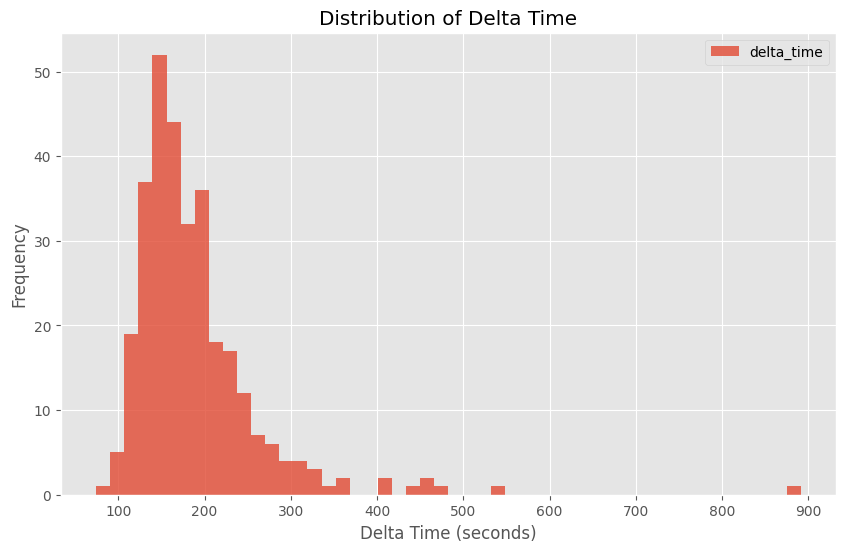

In [6]:
# ETA distribution estimated_time va predict_time (same plot, use different colors and transparency)
plt.figure(figsize=(10, 6))
plt.hist(df['estimate_time'], bins=50, alpha=0.8, label='estimated_time')
plt.hist(df['predict_time'], bins=50, alpha=0.5, label='predict_time')
plt.xlabel('Time (seconds)')   
plt.ylabel('Frequency')
plt.title('Distribution of Estimated Time and Predicted Time')
plt.legend()
plt.show()

#delta_time distribution
plt.figure(figsize=(10, 6))
plt.hist(df['delta_time'], bins=50, alpha=0.8, label='delta_time')
plt.xlabel('Delta Time (seconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Delta Time')
plt.legend()
plt.show()

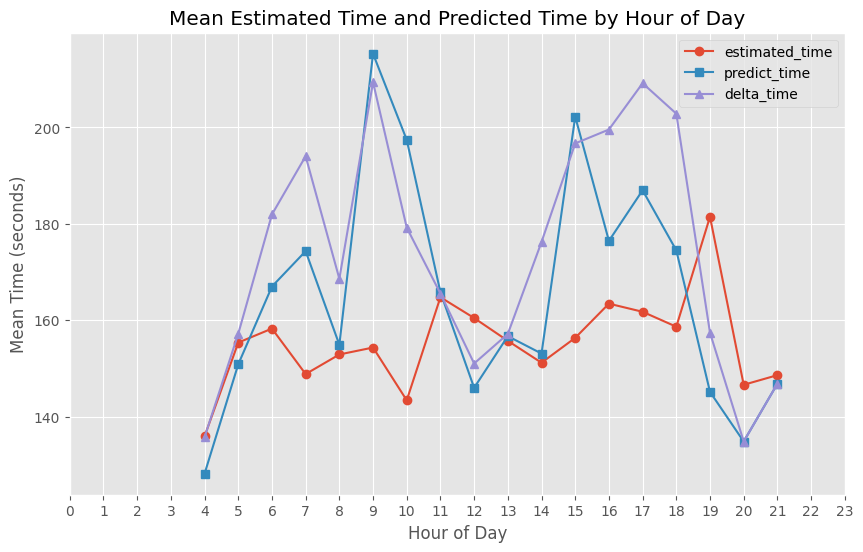

In [7]:
#ETA mean hourly of estimated_time and predict_time (same plot, use different colors and markers)
hourly_means = df.groupby('hour')[['estimate_time', 'predict_time', 'delta_time']].mean().reset_index()
plt.figure(figsize=(10, 6))
plt.plot(hourly_means['hour'], hourly_means['estimate_time'], marker='o', label='estimated_time')
plt.plot(hourly_means['hour'], hourly_means['predict_time'], marker='s', label='predict_time')
plt.plot(hourly_means['hour'], hourly_means['delta_time'], marker='^', label='delta_time')
plt.xlabel('Hour of Day')
plt.ylabel('Mean Time (seconds)')
plt.title('Mean Estimated Time and Predicted Time by Hour of Day')
plt.xticks(range(0, 24))
plt.legend()
plt.show()


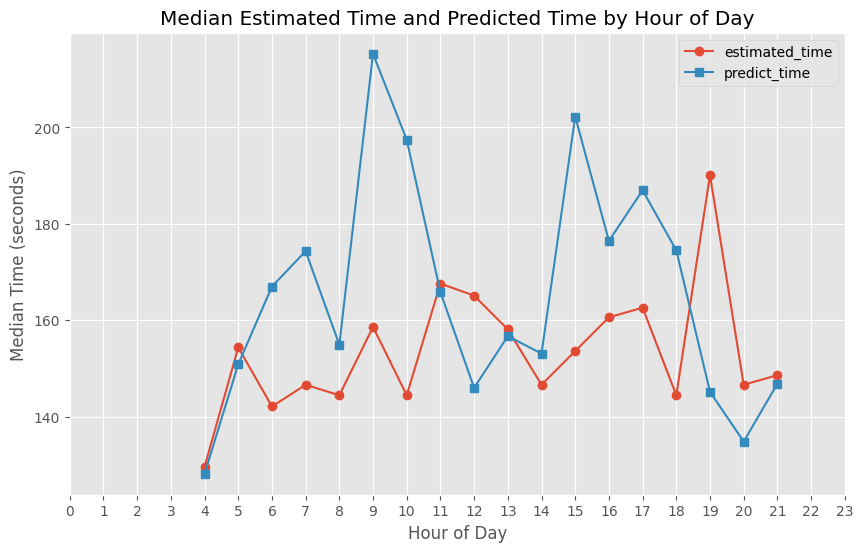

In [8]:
#median hourly of estimated_time and predict_time (same plot, use different colors and markers)
hourly_medians = df.groupby('hour')[['estimate_time', 'predict_time', 'delta_time']].median().reset_index()
plt.figure(figsize=(10, 6))
plt.plot(hourly_medians['hour'], hourly_medians['estimate_time'], marker='o', label='estimated_time')
plt.plot(hourly_medians['hour'], hourly_medians['predict_time'], marker='s', label='predict_time')
plt.xlabel('Hour of Day')
plt.ylabel('Median Time (seconds)')
plt.title('Median Estimated Time and Predicted Time by Hour of Day')
plt.xticks(range(0, 24))
plt.legend()
plt.show()

In [10]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(name, y_true, y_pred):
    return {
        "method": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "Bias": np.mean(y_pred - y_true)
    }

results = []

results.append(evaluate(
    "API estimate_time",
    df["delta_time"],
    df["estimate_time"]
))

results.append(evaluate(
    "Median by Hour predict_time",
    df["delta_time"],
    df["predict_time"]
))

pd.DataFrame(results)

,method,MAE,RMSE,Bias
0,API estimate_time,50.133744,84.449578,-30.816608
1,Median by Hour predict_time,44.408224,76.900419,-15.513946


In [12]:
df_cop = df.copy()
df_cop["api_residual"] = df_cop["delta_time"] - df_cop["estimate_time"]

In [13]:
df_cop["api_residual"] = df_cop["delta_time"] - df_cop["estimate_time"]
df_cop["api_abs_error"] = abs(df_cop["api_residual"])

api_error_by_hour = (
    df_cop.groupby("hour")
    .agg(
        count=("delta_time", "count"),
        actual_mean=("delta_time", "mean"),
        api_mean=("estimate_time", "mean"),
        residual_mean=("api_residual", "mean"),
        residual_median=("api_residual", "median"),
        api_mae=("api_abs_error", "mean")
    )
    .reset_index()
)

api_error_by_hour

,hour,count,actual_mean,api_mean,residual_mean,residual_median,api_mae
0,4,5,135.736745,135.910000,-0.173255,-6.271166,19.882771
1,5,16,157.201073,155.370000,1.831073,-1.251926,25.423799
2,6,21,181.952200,158.271429,23.680772,22.003385,49.622017
3,7,23,194.033774,148.833913,45.199861,32.637942,57.946080
4,8,12,168.614315,152.900833,15.713482,9.407031,33.068421
5,9,5,209.387027,154.342000,55.045027,65.957367,55.045027
6,10,13,179.225385,143.390000,35.835385,52.991904,53.523279
7,11,6,165.532824,164.776667,0.756157,-8.053517,22.731504
8,12,7,151.026937,160.467143,-9.440206,4.581171,21.365893
9,13,15,157.159670,155.732000,1.427670,-0.487935,27.791612


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

df_model = df.copy()
df_model["api_residual"] = df_model["delta_time"] - df_model["estimate_time"]

train_df, test_df = train_test_split(
    df_model,
    test_size=0.2,
    random_state=42
)

median_residual_by_hour = train_df.groupby("hour")["api_residual"].median()
global_median_residual = train_df["api_residual"].median()

pred_residual = (
    test_df["hour"]
    .map(median_residual_by_hour)
    .fillna(global_median_residual)
)

test_df["corrected_eta"] = test_df["estimate_time"] + pred_residual

In [16]:
def evaluate(name, y_true, y_pred):
    return {
        "method": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "Bias": np.mean(y_pred - y_true)
    }

results = []

results.append(evaluate(
    "API estimate_time",
    test_df["delta_time"],
    test_df["estimate_time"]
))

results.append(evaluate(
    "Median by Hour predict_time",
    test_df["delta_time"],
    test_df["predict_time"]
))

results.append(evaluate(
    "API + Median Residual by Hour",
    test_df["delta_time"],
    test_df["corrected_eta"]
))

pd.DataFrame(results).sort_values("MAE")

,method,MAE,RMSE,Bias
1,Median by Hour predict_time,43.316759,66.163764,-13.083757
2,API + Median Residual by Hour,48.116288,70.876105,-7.842815
0,API estimate_time,51.005793,76.480016,-26.761983
